# Week 7 Development Notebook

## 1. Environment and shared infrastructure

### Design decisions

**State representation.** Integer states (0..499) end-to-end. Q-table is a `numpy.ndarray` of shape (500, 6); model entries are keyed by `(int_state, int_action)`. A `decode_state()` helper returns the (taxi_row, taxi_col, passenger_loc, destination) tuple and is reserved for diagnostics, logging, and post-hoc analysis only, never agent hot paths.

**Environment.** Gymnasium `Taxi-v4` in deterministic mode (default). The project-level environment class wraps `gym.make("Taxi-v4")`, exposes `reset(seed=None)` and `step(action)` returning integer states alongside `terminated` and `truncated` flags, and is agnostic to any Gymnasium wrappers stacked beneath it (e.g., the Epic 5 mutation wrapper).

**Seeding.** All determinism flows through `reset(seed=...)`. There is no construction-time seed; the env is constructed seedless and the caller (typically the training loop driver) seeds the env at the first `reset()` of each run. This yields one authoritative source of determinism per run, supports the multi-seed experiment loop pattern, and avoids the footgun where a construction-time seed could be silently overridden by a later `reset(seed=...)` call.

**Episode truncation.** Unsolved episodes truncate at step 200 via Gymnasium's `TimeLimit` wrapper, signaled by `truncated=True` (distinct from `terminated=True` for goal completion). Agents must distinguish the two when computing Q-update targets.

**Agent interface.** Agents subclass an abstract `Agent` base class and implement `act(state)` and `learn(state, action, reward, next_state, terminated, truncated)`. `learn()` returns a flexible dict; the training loop merges keys it recognizes (`wall_time_planning`, `n_planning_updates`) into per-episode aggregates and fills defaults for missing keys. Trivial agents may return an empty dict.

**Trace schema (per-episode rows; refactored 2026-04-28).** Columns: `agent_id`, `seed`, `episode`, `total_reward`, `num_steps`, `cumulative_steps`, `terminated`, `truncated`, `wall_time_episode`, `wall_time_planning_episode`, `n_planning_updates_episode`, `cumulative_planning_updates`. One row per episode rather than per real step. Per-step transition data (`state`, `action`, `next_state`) is discarded; per-step timing is summed into `wall_time_episode` (per-step time = `wall_time_episode / num_steps` when needed). The `cumulative_steps` and `cumulative_planning_updates` columns make both axes available for plotting model-based RL agents (real-step axis for sample efficiency; planning-update axis for compute cost). This schema reduced trace files by roughly two orders of magnitude (Q-learning went from ~12 MB per run to ~50 KB) without losing the data needed for the planned visualizations or the computational-trade-off analysis. The original per-step schema is reachable via the `record_per_step=True` flag on `TrainingLoop`, which currently raises `NotImplementedError` until forensic per-step recording is needed.

**Persistence.** One trace CSV per `(agent_id, seed)` run, written under `data/{agent_id}/trace_seed_{seed}.csv`, with a matching `config_seed_{seed}.json` sidecar containing `agent_id`, `seed`, `num_episodes`, `hyperparams`, and a UTC timestamp. The driver owns I/O; agents never write files. Re-running the same `(agent_id, seed)` overwrites the existing files. Reserved keys (`agent_id`, `seed`, `num_episodes`) cannot appear in user-supplied `hyperparams`; the driver records these from `run()` args directly to keep the sidecar authoritative.

**Storage format.** pandas DataFrame in memory; CSV on disk. In-memory is sufficient for Taxi-scale runs at per-episode granularity.

**Timing.** The driver wraps each real step with `time.perf_counter()` to measure step time, then sums into `wall_time_episode` per row. The agent reports `wall_time_planning` and `n_planning_updates` back to the driver as part of `learn()`'s return dict; both are summed across the episode into `wall_time_planning_episode` and `n_planning_updates_episode`.

In [1]:
# DONE: Build an environment class that wraps Gymnasium Taxi-v4 and presents
# a clean interface to agents.
# Outcome: a class exposing reset(seed=None) and step(action) returning integer
# states, rewards, terminated, and truncated; isolates agents from Gymnasium
# API details; ready to accept Gymnasium wrappers (e.g., the Epic 5 mutation
# wrapper) without changes to the class itself. Also exposes num_actions and
# num_states so callers can construct agents sized to the env without holding
# a reference to the env itself. All seeding flows through reset(seed=...) so
# that there is one authoritative source of determinism per run.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from taxi_env import TaxiEnv

env = TaxiEnv()
print(f"num_actions: {env.num_actions}")
print(f"num_states:  {env.num_states}")

state = env.reset(seed=42)
print(f"Initial state (int): {state}")
print(f"Decoded (taxi_row, taxi_col, passenger_loc, destination): {env.decode_state(state)}")

for step_i in range(5):
    next_state, reward, terminated, truncated = env.step(action=0)
    print(
        f"step={step_i} action=0 -> next_state={next_state} "
        f"reward={reward} terminated={terminated} truncated={truncated} "
        f"decoded={env.decode_state(next_state)}"
    )
    if terminated or truncated:
        break

num_actions: 6
num_states:  500
Initial state (int): 386
Decoded (taxi_row, taxi_col, passenger_loc, destination): (3, 4, 1, 2)
step=0 action=0 -> next_state=486 reward=-1.0 terminated=False truncated=False decoded=(4, 4, 1, 2)
step=1 action=0 -> next_state=486 reward=-1.0 terminated=False truncated=False decoded=(4, 4, 1, 2)
step=2 action=0 -> next_state=486 reward=-1.0 terminated=False truncated=False decoded=(4, 4, 1, 2)
step=3 action=0 -> next_state=486 reward=-1.0 terminated=False truncated=False decoded=(4, 4, 1, 2)
step=4 action=0 -> next_state=486 reward=-1.0 terminated=False truncated=False decoded=(4, 4, 1, 2)


In [2]:
# DONE: Build a training-loop driver that runs any agent satisfying a known
# interface against the environment class.
# Outcome: a TrainingLoop class that takes an Agent (subclass of the abstract
# base) plus an env, agent_id, output_dir, and hyperparams; runs a configurable
# number of episodes from a given seed; records per-episode aggregated traces
# (the schema in the design decisions cell); writes a CSV trace and a JSON
# config sidecar to data/{agent_id}/. Smoke-tested below with a concrete
# random-action agent.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd

from agent import Agent
from taxi_env import TaxiEnv
from training_loop import TrainingLoop


class RandomActionAgent(Agent):
    def __init__(self, num_actions: int, seed: int = 0):
        self.num_actions = num_actions
        self.rng = np.random.default_rng(seed)

    def act(self, state):
        return int(self.rng.integers(0, self.num_actions))

    def learn(self, state, action, reward, next_state, terminated, truncated):
        return {}


env = TaxiEnv()
agent = RandomActionAgent(num_actions=env.num_actions)
loop = TrainingLoop(
    env=env,
    agent=agent,
    agent_id="random_demo",
    output_dir=Path.cwd().parent / "data",
    hyperparams={"policy": "uniform_random"},
)

trace = loop.run(num_episodes=3, seed=0)

print(f"trace rows (one per episode): {len(trace)}")
print(f"per-episode step counts:      {trace['num_steps'].tolist()}")
print(f"total reward:                 {trace['total_reward'].sum():.1f}")
print(f"total real steps:             {int(trace['num_steps'].sum())}")
print()
print("Trace:")
print(trace.to_string())
print()
print("Files written:")
for p in sorted((Path.cwd().parent / "data" / "random_demo").iterdir()):
    print(f"  {p.relative_to(Path.cwd().parent)}")

trace rows (one per episode): 3
per-episode step counts:      [200, 200, 200]
total reward:                 -2571.0
total real steps:             600

Trace:
      agent_id  seed  episode  total_reward  num_steps  cumulative_steps  terminated  truncated  wall_time_episode  wall_time_planning_episode  n_planning_updates_episode  cumulative_planning_updates
0  random_demo     0        0        -911.0        200               200       False       True           0.000870                         0.0                           0                            0
1  random_demo     0        1        -812.0        200               400       False       True           0.000832                         0.0                           0                            0
2  random_demo     0        2        -848.0        200               600       False       True           0.000877                         0.0                           0                            0

Files written:
  data/random_demo/config_

## 2. Q-learning baseline

In [3]:
# DONE: Build a QLearningAgent class implementing pure tabular Q-learning.
# Outcome: a concrete subclass of Agent with constructor params
# (num_states, num_actions, alpha, epsilon, gamma, seed); a Q-table initialized
# to zeros; epsilon-greedy act() with random tiebreak among Q-maxes; one-step
# Q-update in learn() with the bootstrap suppressed when terminated=True
# (truncated alone does not suppress, since a time-limit cutoff state still
# has real future value). Hyperparameters are fixed (no decay) since the goal
# is benchmarking, not optimization.

# DONE: Run a learning-demonstration of QLearningAgent.
# Outcome: use TrainingLoop to run the agent for 5000 episodes from one seed,
# persist the trace to data/q_learning/, and confirm that learning is
# occurring. Minimum signal: trailing-50 mean reward materially exceeds
# leading-50 mean reward; stronger signal: trailing termination rate exceeds
# leading termination rate.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from q_learning_agent import QLearningAgent
from taxi_env import TaxiEnv
from training_loop import TrainingLoop

env = TaxiEnv()
agent = QLearningAgent(
    num_states=env.num_states,
    num_actions=env.num_actions,
    alpha=0.1,
    epsilon=0.1,
    gamma=0.99,
    seed=0,
)
loop = TrainingLoop(
    env=env,
    agent=agent,
    agent_id="q_learning",
    output_dir=Path.cwd().parent / "data",
    hyperparams={
        "alpha": 0.1,
        "epsilon": 0.1,
        "gamma": 0.99,
    },
)

trace = loop.run(num_episodes=5000, seed=0)

leading = trace.head(50)
trailing = trace.tail(50)

print(f"total episodes:    {len(trace)}")
print(f"total real steps:  {int(trace['num_steps'].sum())}")
print()
print(f"leading-50 mean reward:   {leading['total_reward'].mean():.2f}")
print(f"trailing-50 mean reward:  {trailing['total_reward'].mean():.2f}")
print()
print(f"leading-50 mean steps:    {leading['num_steps'].mean():.1f}")
print(f"trailing-50 mean steps:   {trailing['num_steps'].mean():.1f}")
print()
print(f"leading-50 termination rate (goal reached):  {leading['terminated'].mean():.0%}")
print(f"trailing-50 termination rate (goal reached): {trailing['terminated'].mean():.0%}")
print()
print("Files written:")
for p in sorted((Path.cwd().parent / "data" / "q_learning").iterdir()):
    print(f"  {p.relative_to(Path.cwd().parent)}")

total episodes:    5000
total real steps:  146887

leading-50 mean reward:   -386.20
trailing-50 mean reward:  2.70

leading-50 mean steps:    198.6
trailing-50 mean steps:   14.3

leading-50 termination rate (goal reached):  10%
trailing-50 termination rate (goal reached): 100%

Files written:
  data/q_learning/config_seed_0.json
  data/q_learning/trace_seed_0.csv


## 3. Sample-efficiency visualizations

In [4]:
# DONE: Build a load_traces helper.
# Outcome: a function in src/ that takes one or more agent directories under
# data/, globs trace_seed_*.csv across them, concatenates into one tidy
# pandas DataFrame, and returns it. Downstream visualizations consume this
# DataFrame directly without each plot function having to do its own I/O.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from load_traces import load_traces

q_learning_dir = Path.cwd().parent / "data" / "q_learning"
traces = load_traces(q_learning_dir)

print(f"loaded rows: {len(traces)}")
print(f"agent_ids:   {sorted(traces['agent_id'].unique().tolist())}")
print(f"seeds:       {sorted(traces['seed'].unique().tolist())}")
print()
print("First three rows:")
print(traces.head(3).to_string())

loaded rows: 5000
agent_ids:   ['q_learning']
seeds:       [0]

First three rows:
     agent_id  seed  episode  total_reward  num_steps  cumulative_steps  terminated  truncated  wall_time_episode  wall_time_planning_episode  n_planning_updates_episode  cumulative_planning_updates
0  q_learning     0        0        -605.0        200               200       False       True           0.001242                         0.0                           0                            0
1  q_learning     0        1        -605.0        200               400       False       True           0.001169                         0.0                           0                            0
2  q_learning     0        2        -641.0        200               600       False       True           0.001210                         0.0                           0                            0


saved: img/cumulative_reward.png


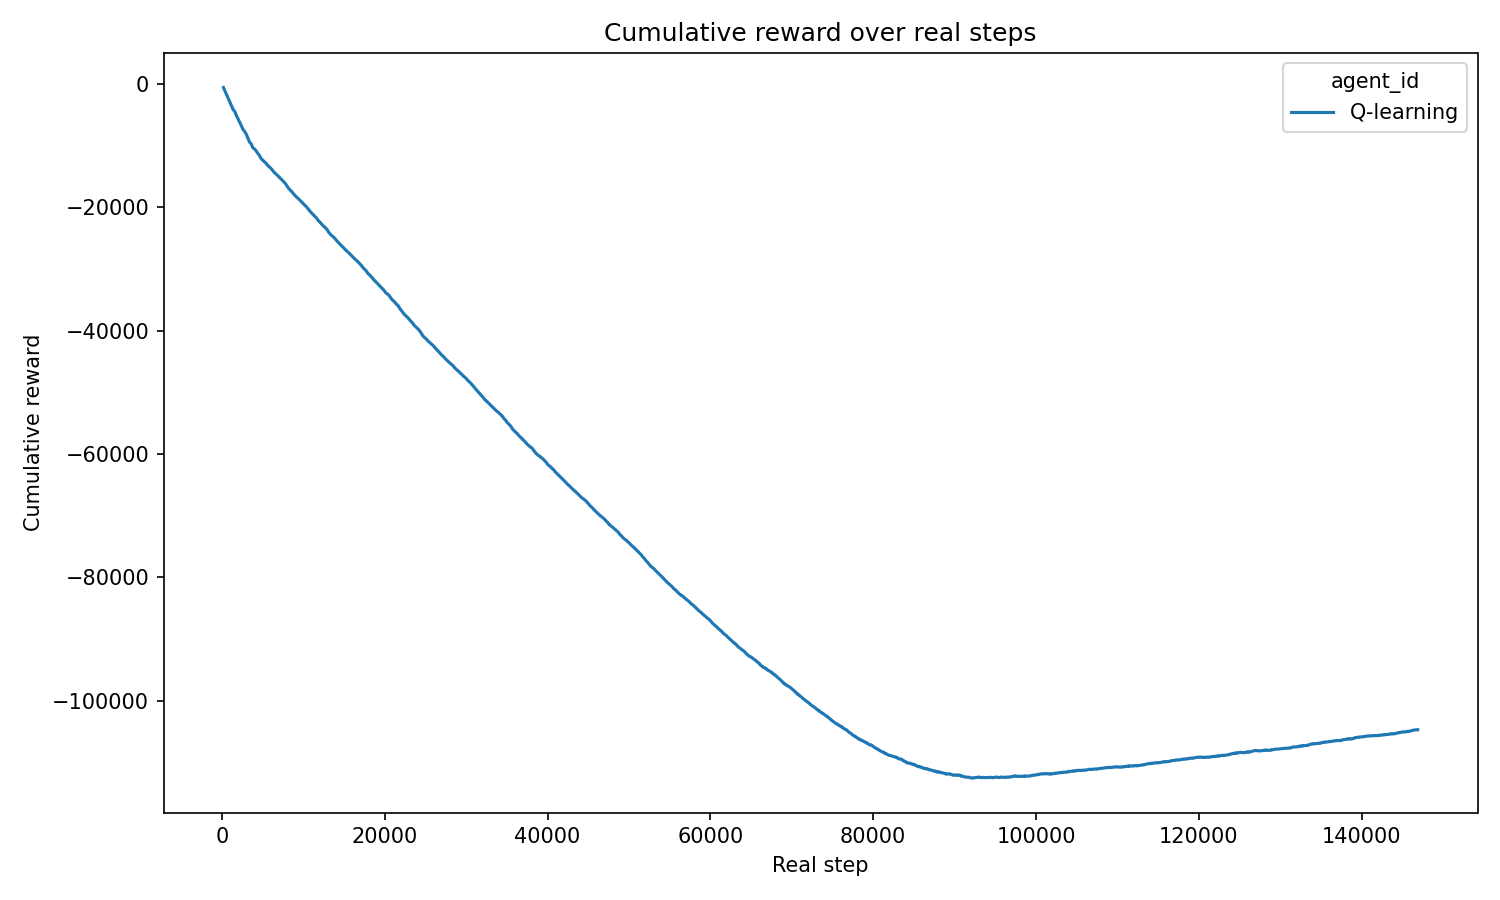

In [5]:
# DONE: Build the cumulative-reward-over-real-steps line plot.
# Outcome: a function that takes a tidy traces DataFrame, computes per-run
# cumulative reward, and renders a seaborn line plot with one curve per agent
# (mean across seeds, 95% CI band). Saves to img/cumulative_reward.png. The
# data prep step is unit-tested for shape; the rendering is smoke-tested for
# file existence. An optional label_map keyword maps the machine-friendly
# agent_id to a display label for the legend.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from IPython.display import Image
from load_traces import load_traces
from visualizations import plot_cumulative_reward

q_learning_dir = Path.cwd().parent / "data" / "q_learning"
traces = load_traces(q_learning_dir)

img_path = Path.cwd().parent / "img" / "cumulative_reward.png"
img_path.parent.mkdir(parents=True, exist_ok=True)
plot_cumulative_reward(traces, img_path, label_map={"q_learning": "Q-learning"})

print(f"saved: {img_path.relative_to(Path.cwd().parent)}")
Image(filename=str(img_path))

saved: img/episodes_to_optimal.png


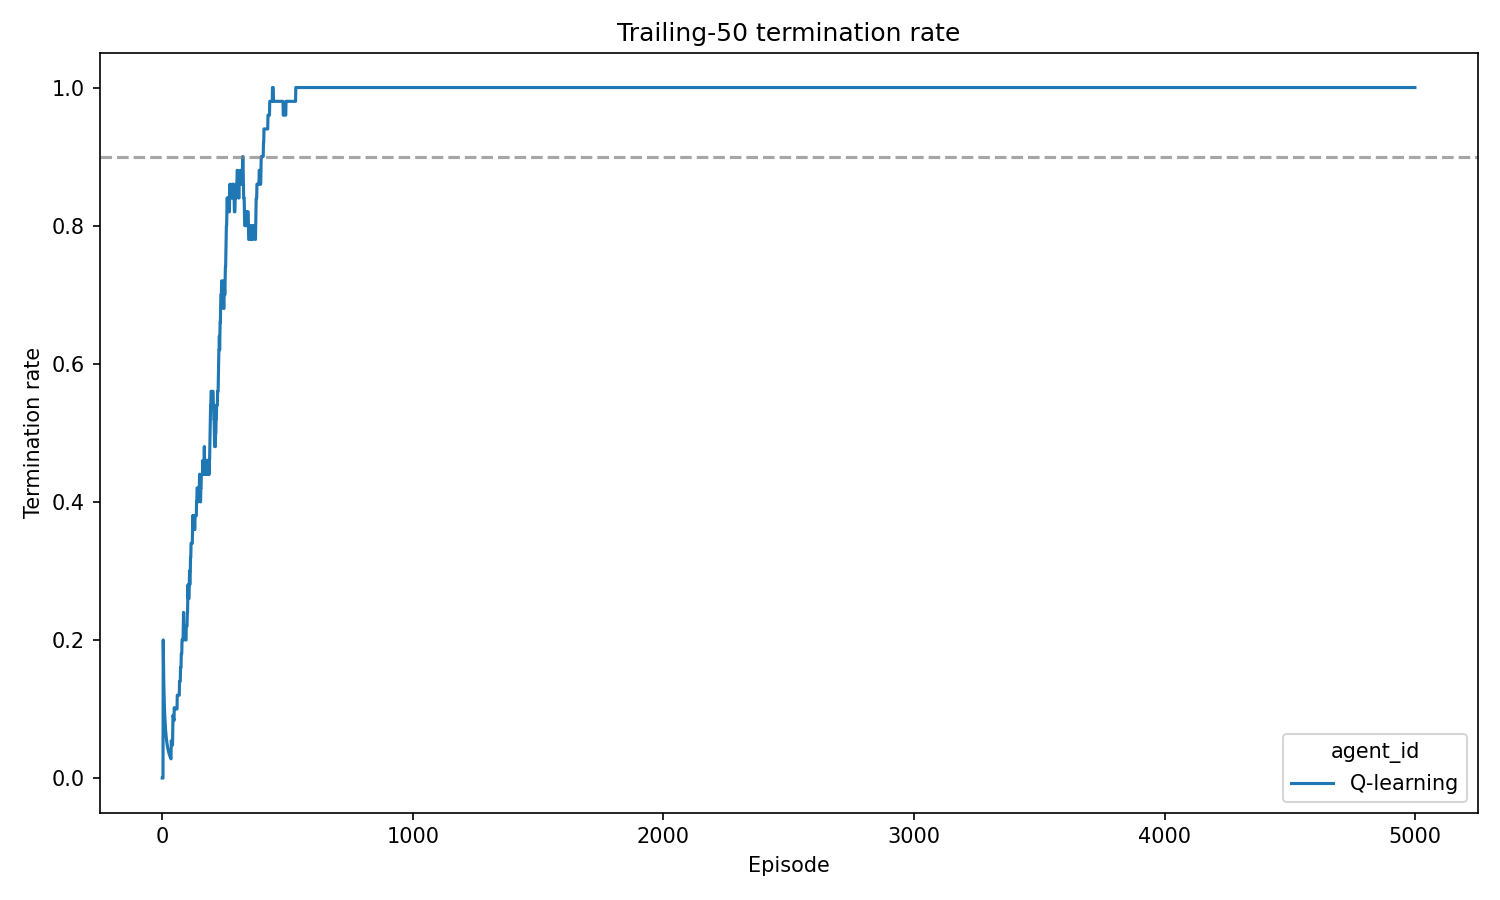

In [12]:
# DONE: Build the trailing-50 termination rate line plot (episodes-to-optimal).
# Outcome: a function that takes a tidy traces DataFrame, computes a per-agent
# per-episode trailing-50 termination rate, and renders a seaborn line plot
# (mean across seeds, 95% CI band). Threshold is set post-hoc and overlaid as
# a horizontal dashed line. Saves to img/episodes_to_optimal.png.

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from IPython.display import Image
from load_traces import load_traces
from visualizations import plot_termination_rate

q_learning_dir = Path.cwd().parent / "data" / "q_learning"
traces = load_traces(q_learning_dir)

img_path = Path.cwd().parent / "img" / "episodes_to_optimal.png"
img_path.parent.mkdir(parents=True, exist_ok=True)
plot_termination_rate(
    traces,
    img_path,
    threshold=0.9,
    window=50,
    label_map={"q_learning": "Q-learning"},
)

print(f"saved: {img_path.relative_to(Path.cwd().parent)}")
Image(filename=str(img_path))

In [7]:
# TODO: Build the steps-to-threshold scalar and bar chart.
# Outcome: two functions in src/. The first, compute_threshold(traces,
# fraction), returns a scalar T derived from the data (e.g., a fraction of
# the best agent's final cumulative reward). The second, steps_to_threshold(
# trace, T), returns the per-run scalar (number of real steps until
# cumulative reward first reaches T). The bar chart renders one bar per
# agent, height = mean steps-to-threshold across seeds with 95% CI error
# bars. Saves to img/steps_to_threshold.png.

In [8]:
# TODO: Validate the visualization pipeline against the existing q_learning trace.
# Outcome: a notebook cell that loads the q_learning trace via load_traces and
# renders all three plots end-to-end. Plots will look thin (one agent, one
# seed, no error bands), but the plumbing is exercised before more agents land
# in Epics 4, 6, and 7.

## 4. Tabular model and Dyna-Q

## 5. Dynamic environment

## 6. Dyna-Q+

## 7. Prioritized sweeping

## 8. Convergence runs

## 9. Synthesis

## 10. Optional: NN dynamics model